In [1]:
import sys 
import os 
sys.path.append(os.path.abspath('..'))

In [2]:
from src.data_loader import DataLoader

dataLoader = DataLoader()
dataLoader.download()
dataLoader.clean()
dataLoader.add_features()
dataLoader.add_technical_indicators()
sp500 = dataLoader.data

In [3]:
import pandas as pd

sp500.index = pd.to_datetime(sp500.index)
sp500 = sp500.loc["1990-01-01":].copy()
sp500 = sp500.dropna(subset=sp500.columns[sp500.columns != "Tomorrow"])

In [4]:
import joblib
from src.evaluate import summary_metrics

# Load all predictions
predictions_lr  = joblib.load('../models/predictions_lr.joblib')
predictions_mlp = joblib.load('../models/predictions_mlp.joblib')
predictions_knn = joblib.load('../models/predictions_knn.joblib')
predictions_rf  = joblib.load('../models/predictions_rf.joblib')
predictions_svm = joblib.load('../models/predictions_svm.joblib')

In [5]:
# Summary table
results = pd.DataFrame([
    summary_metrics(predictions_rf, "Random Forest", sp500),
    summary_metrics(predictions_lr, "Logistic Regression", sp500),
    summary_metrics(predictions_mlp, "MLP", sp500),
    summary_metrics(predictions_knn, "KNN", sp500),
    summary_metrics(predictions_svm, "SVM", sp500),
])

results

,Model,Precision,Sharpe Ratio,Strategy Return,Buy & Hold Return,MA Crossover Return,Number of Trades
0,Random Forest,0.5795,0.5529,0.8392,2.1098,1.8914,302
1,Logistic Regression,0.5572,0.6557,1.0799,2.1098,1.8914,201
2,MLP,0.5385,0.4669,1.4793,2.1098,1.8914,2219
3,KNN,0.5321,0.2485,0.9343,2.1098,1.8914,2913
4,SVM,0.3750,-0.1675,-0.0478,2.1098,1.8914,8


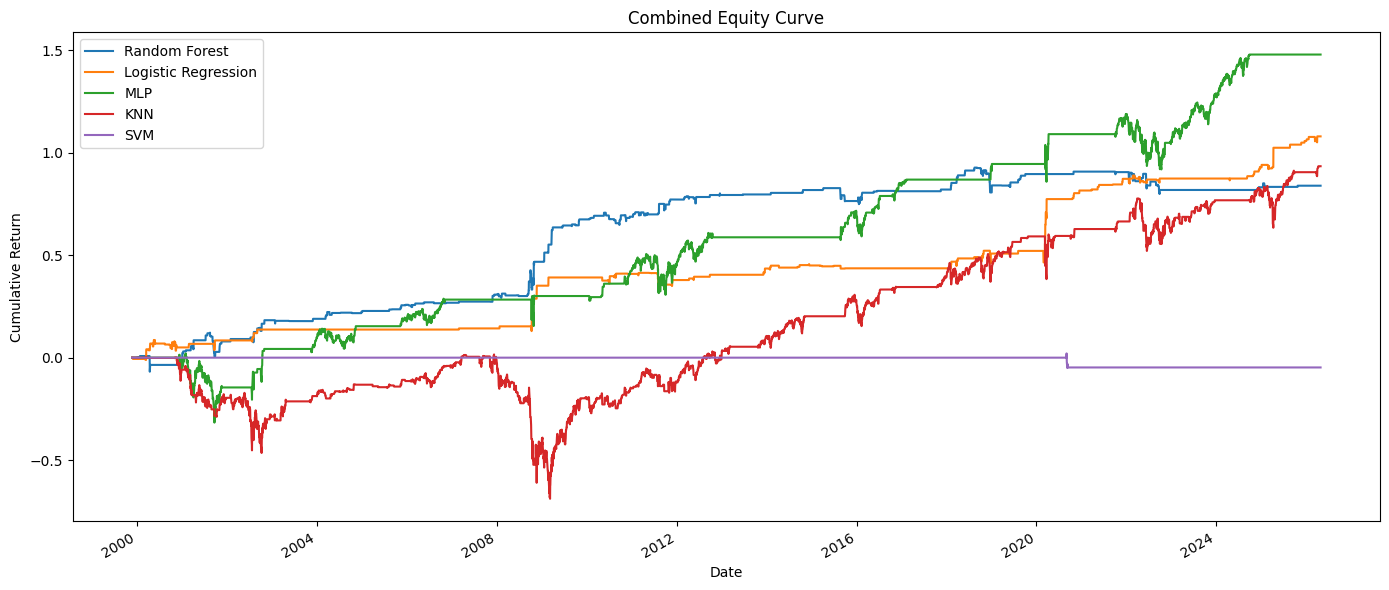

In [6]:
import matplotlib.pyplot as plt 

fig, ax = plt.subplots(figsize=(14, 6))

predictions_rf["Strategy"].cumsum().plot(ax=ax, label="Random Forest")
predictions_lr["Strategy"].cumsum().plot(ax=ax, label="Logistic Regression")
predictions_mlp["Strategy"].cumsum().plot(ax=ax, label="MLP")
predictions_knn["Strategy"].cumsum().plot(ax=ax, label="KNN")
predictions_svm["Strategy"].cumsum().plot(ax=ax, label="SVM")

ax.set_title("Combined Equity Curve")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Return")
ax.legend()
plt.tight_layout()
plt.show()